# Calculating confidence masks

Very low EVI can be overwhelemed by noise, it becomes difficult to identify real patterns vs patterns generated by noise. To do so, we are going to use noise as benchmark (according to instrument specs), and we will look whether out power spectra seats above this noise "floor".

Gaussian Noise is generated for 1000 indipendent series in the script `adding-white-noise-ipynb` and distribution stats at each wavelet period is saved in the file `stats_noise_1000_gaussian.csv` 

In [2]:
import xarray as xr
import pygmt
import pandas as pd

In [3]:
# get file stats_noise.csv
stats_noise = pd.read_csv("stats_noise_1000_gaussian.csv") # this file is generated from adding-white-noise.ipynb
stats_noise.head()

# get the Power EVI Maps
# netcdf file of power for all times
power_all_times = xr.open_dataset("/Users/gb4818/Desktop/wavelets-vegetation-hpc/world_5km_output_sumpower_merged_v0.nc", 
                                  chunks={'period': 10}) 
# this file (world_5km_output_sumpower_merged_v0.nc) can be generated from running power-analysis-timeseries-complete-scales_windows.py without windowing, 
# then merging all 300 job array ouput in a single csv and subsequantly converting to netcdf using csv_to_netcdf.py


In [4]:
# now just isolating the different periods I'm interested in

### ALL TIMES - Actual power
triyearly_all = power_all_times.rect_power.sel(period=slice(115.1,123.4))
biyearly_all = power_all_times.rect_power.sel(period=slice(174.5, 187.))
yearly_all = power_all_times.rect_power.sel(period=slice(349, 374.))
twoyear_all = power_all_times.rect_power.sel(period=slice(697.9, 748))
fiveyear_all = power_all_times.rect_power.sel(period=slice(1718.5,1841.8))
sevenyear_all = power_all_times.rect_power.sel(period=slice(2430.3, 2604.7))

all_times_datasets  = {
    '4 months': triyearly_all,
    '6 months': biyearly_all,
    '1 year': yearly_all,
    # 'Nino': nino_all,
    '2 years': twoyear_all,
    '5 years': fiveyear_all,
    '7 years': sevenyear_all
}


In [5]:
# approximate the period col to 1 decimal point
stats_noise['period'] = stats_noise['period'].round(1)

In [6]:
# Now I want to check the grids and check whether the power at these periods is above the noise threshold from the csv
# I'll use the mean_rect_power as a reference value

def get_noise_threshold_mask(noise_series_stats, xarray_data, threshold_col: str = 'mean_rect_power'):

    #create a series for better alignment
    noise_series_stats = noise_series_stats.set_index('period')[threshold_col]

    # Align noise thresholds with the periods in the DataArray, will automatically filter to matching periods
    noise_series_stats = noise_series_stats.reindex(xarray_data.period.values)

    # Convert noise values to an xarray DataArray with matching coordinate
    noise_da = xr.DataArray(
        noise_series_stats.values,
        coords={'period': xarray_data.period.values},
        dims=['period'],
        name= threshold_col
    )

    # Compare directly — xarray will broadcast over lat/lon automatically
    mask_above_noise = xarray_data > noise_da

    return mask_above_noise

In [7]:
# apply the function to all datasets
power_masks_all = {}
for key, data in all_times_datasets.items():
    power_masks_all[key] = get_noise_threshold_mask(stats_noise, data, threshold_col='mean_rect_power')

## Mask logic

Let's consider a point (let's call it point **a**) that for the period window *1year* has:

- scale 1 (325.6) = FALSE
- scale 2 (349.0) = FALSE
- scale 3 (374) = TRUE
- => summary mask for 1 year: FALSE

the rule could be:

- *if TRUE periods > N/2 --> summary mask = TRUE*

- *if FALSE periods => N/2 --> summary mask = FALSE*


where N is the number of periods

<small>*TRUE means that the value of the power is above threshold<small>

In [ ]:
# create a summary mask for each periodicity across all time windows
summary_masks = {}

for key, da in power_masks_all.items():
    # Count True values across periods
    true_count = da.sum(dim="period")  # Since the DataArray has dtype bool, summing over the period dimension counts how many True values exist for each grid cell.
    N = da.sizes["period"]
    
    # Majority rule: TRUE if > N/2
    summary_mask = true_count > (N / 2)
    
    # metadata
    summary_mask.name = f"{key}_summary_mask"
    summary_mask.attrs["description"] = f"Summary mask for {key} (TRUE if > N/2 periods TRUE)"
    
    summary_masks[key] = summary_mask



Plotting dataset 2000-2025 - periods 4 months
Plotting dataset 2000-2025 - periods 6 months
Plotting dataset 2000-2025 - periods 1 year
Plotting dataset 2000-2025 - periods 2 years


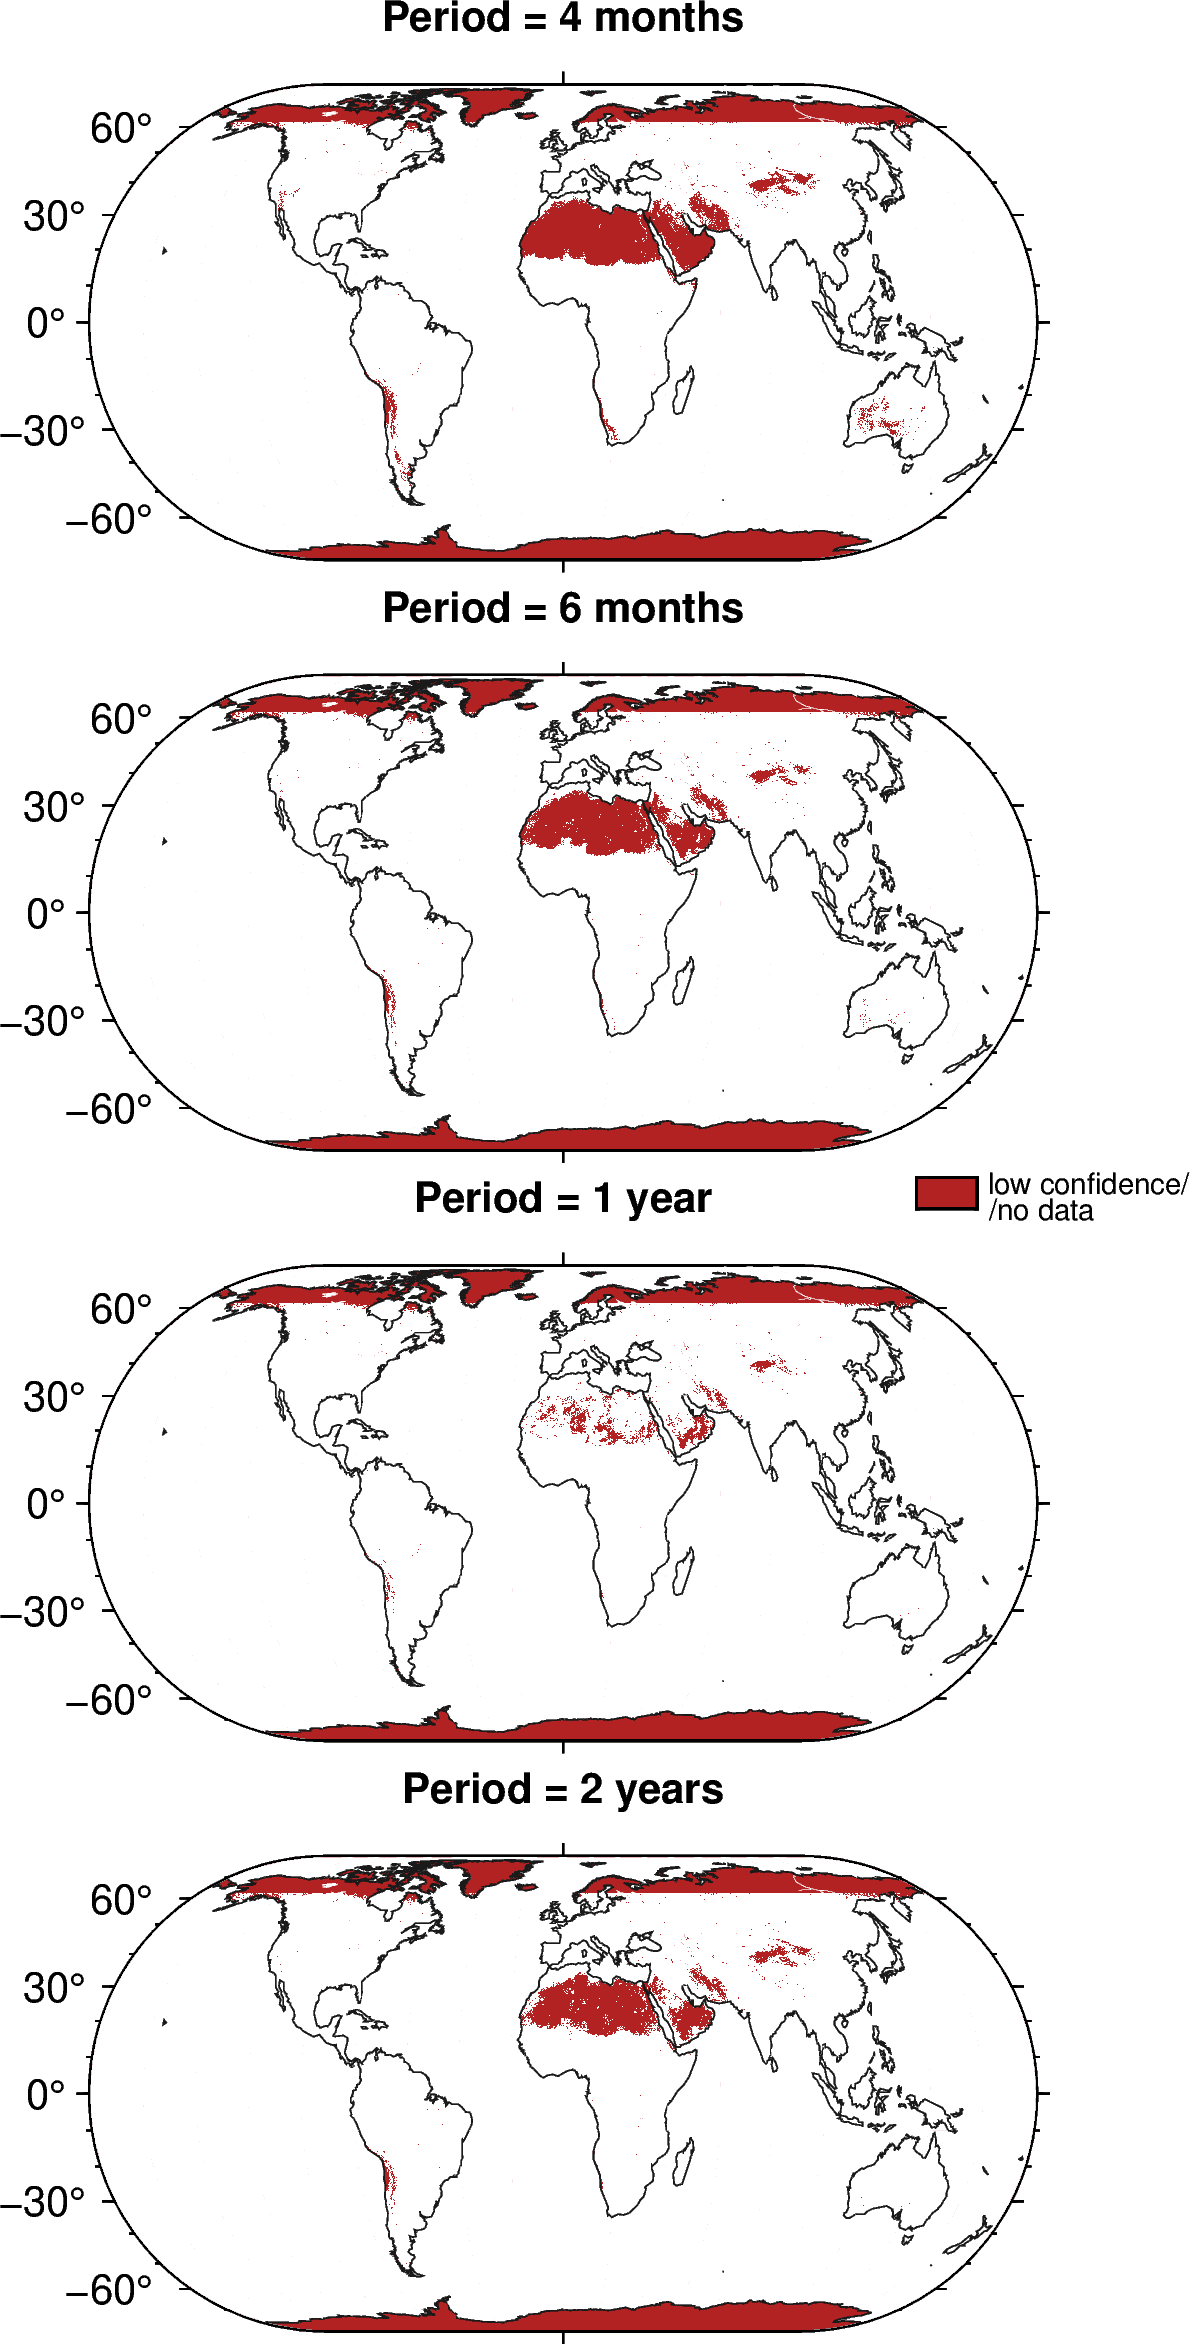

In [9]:
# Visualise the masks. I will make n gmt plots for each period in each dictionary
fig=pygmt.Figure()

for key, dataset in summary_masks.items():
    if key in ['4 months', '6 months', '1 year', '2 years']:
        print(f"Plotting dataset 2000-2025 - periods {key}")

        # Create a colormap for binary data
        cmap = pygmt.makecpt(cmap="firebrick,white", series=(-0.5,1.5,1), continuous=False)
        grid = dataset.astype(int)
        
        # Plot grid
        with pygmt.config(FONT_ANNOT="10p", MAP_FRAME_TYPE="plain", FORMAT_GEO_MAP="ddd", FONT_TITLE="10p", MAP_TITLE_OFFSET="0c"):
            fig.basemap(region="d", projection="Kf8c", frame=["y30f10", "x360", f"Wsne+tPeriod = {key}"])
            fig.grdimage(grid=grid, cmap=cmap)

        # Add coastlines and zero line
        fig.coast(area_thresh="10000", shorelines="1/0.3p,gray10", water="white")
        
        # Shift origin for next plot
        fig.shift_origin(yshift="-5c")  # Shift down for next plot

# shift for legend
fig.shift_origin(yshift="14.5c", xshift="7c") 
# Legend for low confidence areas
fig.basemap(region=[0, 1, 0, 2], projection="X0.5c/0.25c", frame="swen")# basemap without any ticks
rectangle_coords = [[0, 0], [3, 0], [3, 3], [0, 3], [0, 0]] # A 3cm wide rectangle
fig.plot(data=rectangle_coords,fill="firebrick", close=True, pen="black") # plot a rectangle of the same colour as the low confidence areas
fig.text(x=0, y=0, text="low confidence/",font="7p,Helvetica,black",offset="2.3c/0.12c", justify="BR", no_clip=True) # add text next to rectangle
fig.text(x=0, y=0, text="/no data",font="7p,Helvetica,black",offset="1.5c/-0.1c", justify="BR", no_clip=True) # add text next to rectangle


# Show the figure
fig.show()

# save
fig.savefig(f"maps_of_power/confidence_masks_summary.png", dpi=1000, transparent=True)